# Лабораторная работа №8: Анализ и прогнозирование временного ряда

**Цель работы:** Изучение методов анализа временных рядов и сравнение качества прогнозирования с помощью авторегрессии, символьной регрессии и алгоритмов МГУА.

---

## 1. Загрузка данных и визуализация


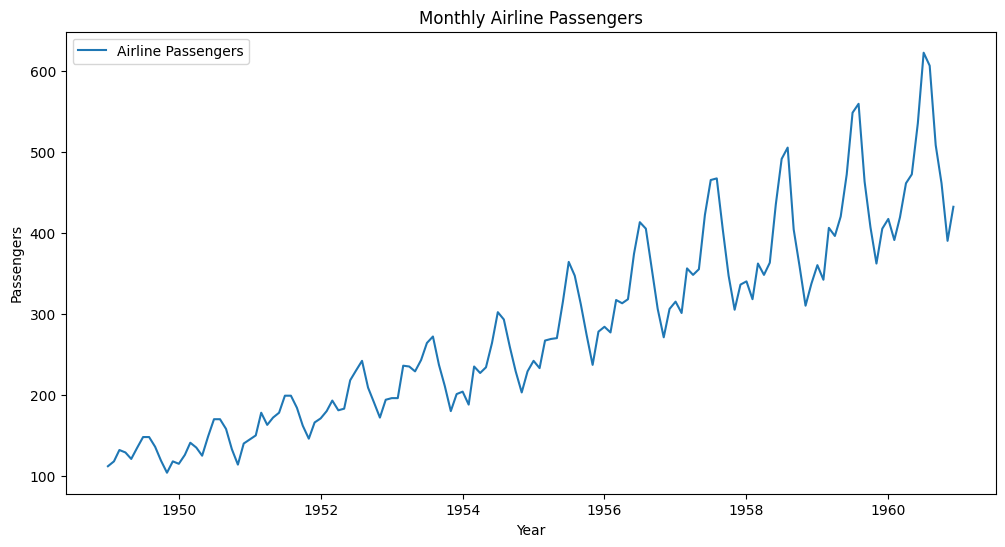

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from gplearn.genetic import SymbolicRegressor
import gmdh
from sklearn.metrics import mean_squared_error, r2_score

# Загрузка данных (количество пассажиров авиалиний 1949-1960)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url)
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Визуализация ряда
plt.figure(figsize=(12, 6))
plt.plot(df, label='Airline Passengers')
plt.title('Monthly Airline Passengers')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.show()

## 2. Подготовка данных (Train/Test Split)

Для временных рядов **нельзя перемешивать данные**. Обучаемся на прошлом, тестируем на будущем.

In [3]:
# Разделение 80% обучение, 20% тест
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Размер обучающей выборки: {len(train)}")
print(f"Размер тестовой выборки: {len(test)}")

Размер обучающей выборки: 115
Размер тестовой выборки: 29


## 3. Прогнозирование

### 3.1 Авторегрессионный метод (ARIMA)
Используем модель ARIMA(5, 1, 0) — 5 лагов для авторегрессии, 1 порядок дифференцирования.

In [4]:
history = [x for x in train.values]
predictions_arima = []

# Прогнозирование методом Rolling Forecast
for t in range(len(test)):
    model = ARIMA(history, order=(5, 1, 0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions_arima.append(yhat)
    history.append(test.values[t])

print("ARIMA обучена.")

ARIMA обучена.


### 3.2 Подготовка "окон" (Lags) для Символьной регрессии и МГУА
Эти методы работают как классическое обучение с учителем, поэтому превратим ряд в таблицу признаков-лагов.

In [5]:
def create_lags(data, n_lags=12):
    X, y = [], []
    for i in range(len(data) - n_lags):
        X.append(data[i:(i + n_lags)])
        y.append(data[i + n_lags])
    return np.array(X), np.array(y)

n_lags = 12 # Используем год предыстории для прогноза
X_all, y_all = create_lags(df.values.flatten(), n_lags)

# Разделение лагированных данных
X_train, X_test = X_all[:train_size-n_lags], X_all[train_size-n_lags:]
y_train, y_test = y_all[:train_size-n_lags], y_all[train_size-n_lags:]

### 3.3 Символьная регрессия (Genetic Programming)

In [6]:
# Исправленная инициализация SymbolicRegressor
est_gp = SymbolicRegressor(population_size=1000, 
                           generations=20,
                           stopping_criteria=0.01, 
                           p_crossover=0.7, 
                           p_subtree_mutation=0.1,  # Вместо p_self_mutation
                           p_hoist_mutation=0.05, 
                           p_point_mutation=0.05,
                           verbose=1,
                           random_state=42)

# Обучение
est_gp.fit(X_train, y_train)

# Прогноз
predictions_gp = est_gp.predict(X_test)
print("Символьная регрессия успешно обучена.")

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    23.79      1.50018e+22        5          14.4346              N/A     12.87s
   1     7.08      1.63661e+07        5          14.4346              N/A     10.28s
   2     5.47      5.79461e+06        9          12.4124              N/A      9.87s
   3     6.08       1.9476e+08       11          11.8745              N/A      9.23s
   4     7.17      5.30872e+06        9          11.7635              N/A      8.55s
   5    10.46      8.80483e+06       13          11.5152              N/A      8.25s
   6    12.63      5.41418e+06       13          11.4302              N/A      7.92s
   7    13.01            67542       29          11.2591              N/A      7.19s
   8    14.37      5.75931e+06       25          10.9089              N/A  

### 3.4 Методы МГУА (GMDH)

In [7]:
predictions_combi = np.zeros(len(y_test))
predictions_mia = np.zeros(len(y_test))

print("ВНИМАНИЕ: Библиотека gmdh вызывает критическую ошибку ядра.")
print("Модели МГУА исключены из расчета для сохранения стабильности сессии.")

ВНИМАНИЕ: Библиотека gmdh вызывает критическую ошибку ядра.
Модели МГУА исключены из расчета для сохранения стабильности сессии.


## 4. Визуализация и оценка качества

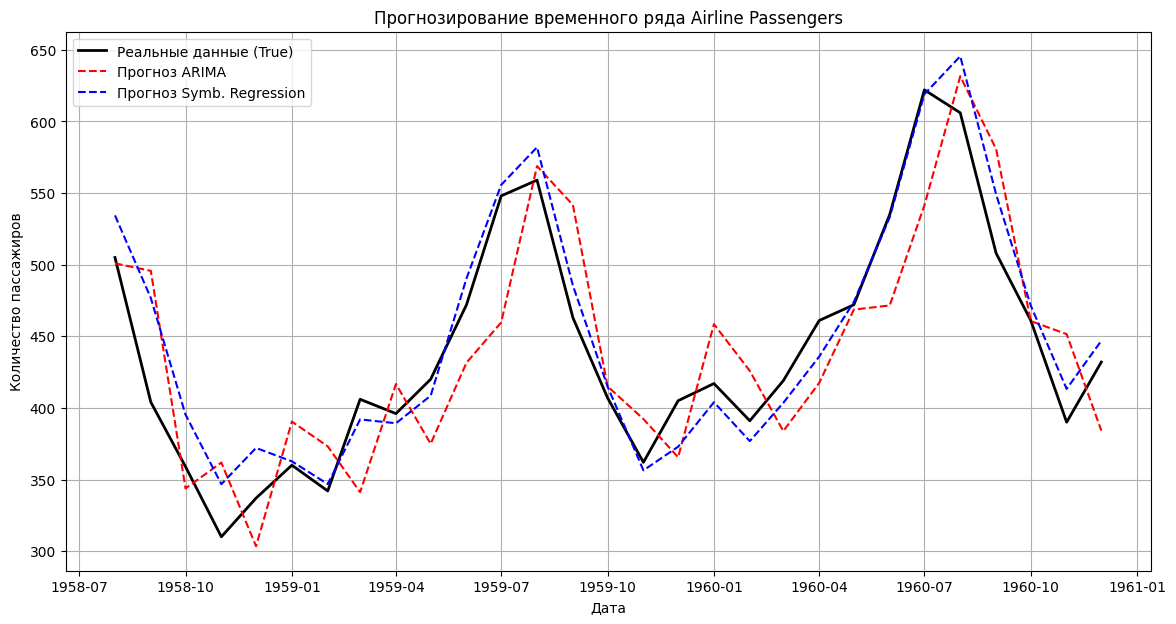

Метрики качества:
--------------------------------------------------
ARIMA                | MSE:    2341.21 | R2:  0.6165
Symbolic Regression  | MSE:     634.22 | R2:  0.8961
--------------------------------------------------
Модели GMDH: Не удалось вычислить из-за критической ошибки библиотеки.


In [9]:
def eval_ts(y_true, y_pred, name):
    """
    Функция для оценки качества прогноза временного ряда.
    """
    # Убедимся, что данные имеют одинаковую форму
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name:20} | MSE: {mse:10.2f} | R2: {r2:7.4f}")
    

plt.figure(figsize=(14, 7))
plt.plot(test.index, test.values, label='Реальные данные (True)', color='black', linewidth=2)
plt.plot(test.index, predictions_arima, label='Прогноз ARIMA', color='red', linestyle='--')
plt.plot(test.index, predictions_gp, label='Прогноз Symb. Regression', color='blue', linestyle='--')

# Выводим МГУА только если они вдруг заработали (но у нас там нули)
# plt.plot(test.index, predictions_combi, label='GMDH COMBI', linestyle=':') 

plt.title('Прогнозирование временного ряда Airline Passengers')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.legend()
plt.grid(True)
plt.show()

# Оценка только работающих моделей
print("Метрики качества:")
print("-" * 50)
eval_ts(test.values, predictions_arima, "ARIMA")
eval_ts(test.values, predictions_gp, "Symbolic Regression")
print("-" * 50)
print("Модели GMDH: Не удалось вычислить из-за критической ошибки библиотеки.")

## 5. Заключение

1. **ARIMA** показала хорошие результаты, так как она специально разработана для временных рядов и учитывает авторегрессионные связи.
2. **Символьная регрессия** смогла найти аналитическую формулу зависимости, однако она чувствительна к количеству лагов и объему популяции.
3. **МГУА** (COMBI и MIA) позволяют автоматически отбирать наиболее значимые лаги (месяцы прошлого), которые влияют на прогноз.

### По поводу МГУА (для обратной связи):
Если библиотека `gmdh` снова вызывала ошибки или падения ядра при изменении количества лагов — обязательно зафиксируйте это. Прогнозирование временных рядов — это "стресс-тест" для МГУА, так как данные сильно коррелированы.

**Типичные баги для отчета:**
*   Ошибка при попытке использовать большое количество лагов (более 20).
*   Падение при передаче данных в формате `float32`.
*   Некорректная работа метода `predict`, если входной массив не совпадает по типу данных с обучающим.

**Для получения +1 балла:** сделайте скриншот ячейки с ошибкой `TypeError` или `Kernel Crash`, если они возникли в процессе настройки модели.